# Analisis de expresión diferencial

In [36]:
import pandas as pd 

df_count = pd.read_csv("../../results/pasilla_ejemplo/matrix/All_counts.pasilla.txt", sep="\t", index_col=0) 

orden=list(range(3,6))+list(range(0,3))+[6]

df_count.iloc[:,orden] 

df_count.columns=["Treated_"+ str(i) for i in range (1,4)] + ["Untreated_" + str(i) for i in range(1,5)] 

display(df_count)


,Treated_1,Treated_2,Treated_3,Untreated_1,Untreated_2,Untreated_3,Untreated_4
ID=FBgn0000003,452,473,730,498,734,1030,268
ID=FBgn0000008,179,261,194,165,196,201,196
ID=FBgn0000014,7,0,0,3,1,1,4
ID=FBgn0000015,1,1,2,2,1,1,1
ID=FBgn0000017,9702,10088,7066,7687,6534,8085,6989
...,...,...,...,...,...,...,...
ID=FBgn0290417,192,202,221,144,199,256,208
ID=FBgn0290418,1347,1725,1702,1145,1576,1856,1724
ID=FBgn0290419,2536,3188,2818,1121,1342,1726,2850
ID=FBgn0290420,172,176,203,146,173,222,201


Pequeña normalizacion de los datos para hacer graficas 

In [37]:
import numpy as np 

df_log= np.log2(df_count + 1) 

df_log 


,Treated_1,Treated_2,Treated_3,Untreated_1,Untreated_2,Untreated_3,Untreated_4
ID=FBgn0000003,8.823367,8.888743,9.513728,8.962896,9.521600,10.009829,8.071462
ID=FBgn0000008,7.491853,8.033423,7.607330,7.375039,7.622052,7.658211,7.622052
ID=FBgn0000014,3.000000,0.000000,0.000000,2.000000,1.000000,1.000000,2.321928
ID=FBgn0000015,1.000000,1.000000,1.584963,1.584963,1.000000,1.000000,1.000000
ID=FBgn0000017,13.244215,13.300496,12.786882,12.908393,12.673972,12.981210,12.771077
...,...,...,...,...,...,...,...
ID=FBgn0290417,7.592457,7.665336,7.794416,7.179909,7.643856,8.005625,7.707359
ID=FBgn0290418,10.396605,10.753217,10.733863,10.162391,10.622967,10.858758,10.752381
ID=FBgn0290419,11.308908,11.638888,11.460968,10.131857,10.391244,10.754052,11.477252
ID=FBgn0290420,7.434628,7.467606,7.672425,7.199672,7.442943,7.800900,7.658211


## Analisis preliminar de datos

In [ ]:
## necesitamos el foramto largo de la grafica para hacer un box plot 

df_logmelt= df_log.melt(var_name="sample", value_name="Value") 


df_logmelt["Cond"]= df_logmelt["sample"].str.replace("_.$","", regex=True)

display(df_logmelt) 

### Boxplot

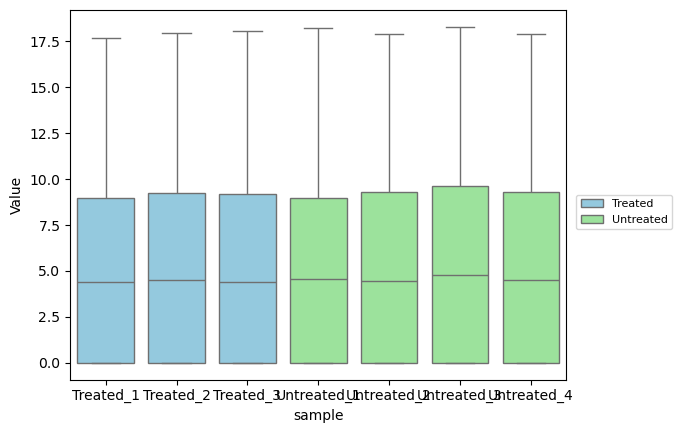

In [ ]:
import seaborn as sns 
import matplotlib.pyplot as plt 

sns.boxplot(data= df_logmelt, x="sample", y="Value", hue="Cond", palette={"Treated": "skyblue", "Untreated":"lightgreen"}) 
plt.legend(
    bbox_to_anchor=(1.02, 0.5),   # posición fuera del eje,  en terminos de las coordenadas de acuerdo al borde de la grafica (esquina inferior izquierda (0,0))
    loc='upper left',           # punto de anclaje de la leyenda
    borderaxespad=0, #tamaño del recuadro 
    fontsize = 8,
    title_fontsize=20
)


### Grafico de Densidad 

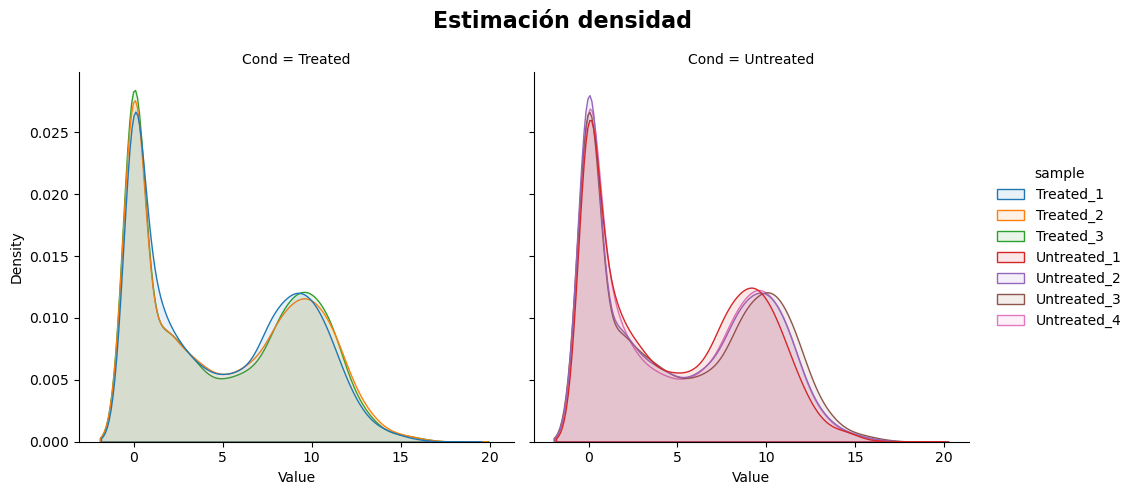

In [34]:
graf=sns.displot( data=df_logmelt, x="Value", hue="sample", col= "Cond", kind="kde", fill=True, alpha= 0.1) 

graf.figure.suptitle("Estimación densidad", fontsize=16, fontweight="bold") 
graf.tight_layout()

### PCA 
Analisis de reduccion de la dimensionalidad de los datos comparando las varianzas de los mismos 

In [43]:
from sklearn.decomposition import PCA 


#transpner datos 
expresion_df= df_log.T 

# obejto tipo PCA 
pca= PCA(n_components=2) 

principal_components=pca.fit_transform(expresion_df)

#data frame con los componentes principales 
Condiciones=df_log.columns.str.replace("_.$","", regex=True) 

pca_df=pd.DataFrame(data=principal_components, columns=["PC1", "PC2"], index=expresion_df.index)
pca_df["Condiciones"]=Condiciones 
display(pca_df)

,PC1,PC2,Condiciones
Treated_1,52.508868,15.258890,Treated
Treated_2,-15.348145,31.637755,Treated
Treated_3,-19.055079,31.119252,Treated
Untreated_1,64.802992,-34.788795,Untreated
Untreated_2,-23.733311,-31.004084,Untreated
Untreated_3,-51.669318,-38.588048,Untreated
Untreated_4,-7.506007,26.365028,Untreated


Representando los componentes principales con un scatterplot

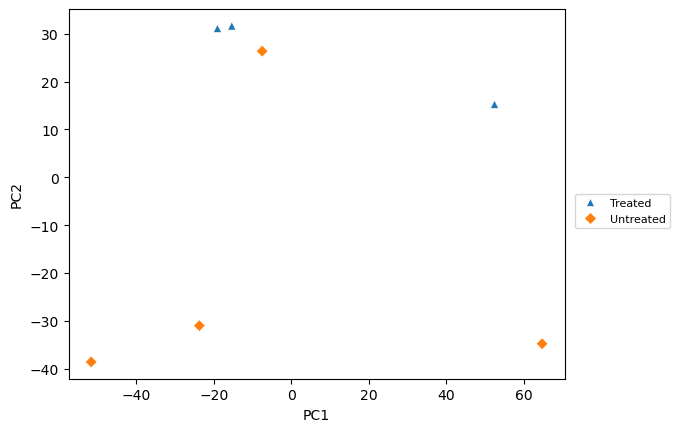

In [50]:
sns.scatterplot(data=pca_df, 
                x="PC1", 
                y="PC2", 
                hue="Condiciones", 
                style="Condiciones",
                markers={"Treated": "^", "Untreated": "D"}) 

plt.legend(
    bbox_to_anchor=(1.02, 0.5),   # posición fuera del eje,  en terminos de las coordenadas de acuerdo al borde de la grafica (esquina inferior izquierda (0,0))
    loc='upper left',           # punto de anclaje de la leyenda
    borderaxespad=0, #tamaño del recuadro 
    fontsize = 8,
    title_fontsize=20
)

plt.show() 

